# 06. Price Signals — 언제, 어떤 가격에 매입할까

구매 담당자의 핵심 질문 "**지금 사야 할까, 더 기다려야 할까**"에 정량 신호를 만듭니다.

### 사용하는 신호

| 신호 | 의미 | 매입 액션 |
|---|---|---|
| **z-score (vs 추세선)** | 추세 대비 얼마나 벗어났나 | z < -1 → 추세 대비 저가, 매입 후보 |
| **Bollinger %B** | 이동평균 ± 2σ 밴드의 어디 있나 | %B < 0 → 밴드 하단 이탈, 평균회귀 기대 |
| **모멘텀 (3개월 ROC)** | 최근 3개월 가격 변화율 | ROC < 0 + z<-1 → 강한 매입 시그널 |
| **계절 보정 가격** | 계절성을 제거한 "실질" 가격 | 실질 가격이 낮을 때 매입 |

### 매입 결정 규칙 (예시)

1. **강한 매입**: z < −1.5 AND momentum < 0 → 평소보다 충분히 싸고 더 떨어지지 않을 가능성
2. **선택적 매입**: −1.5 ≤ z < −0.5 AND 계절 저점 시즌 → 계절성 활용
3. **대기**: |z| < 0.5 → 일반 구간
4. **매입 보류**: z > 1 OR momentum > 5% → 평균 회귀 가능성, 다음 회차 대기

이 규칙은 **출발점 템플릿**입니다. 회사별로 임계값을 조정하세요.

In [ ]:
!pip install -r ../../../requirements.txt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.seasonal import STL
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('../data')

In [3]:
df = pd.read_csv(DATA_DIR / 'sample_purchases.csv', parse_dates=['date']).sort_values('date')
TARGET = 'SKU-A001-COTTON'
series = (df[df['product_id'] == TARGET]
          .set_index('date')['unit_cost_krw']
          .asfreq('MS')
          .interpolate())
print(f'{len(series)} months loaded')

36 months loaded


## 1. 추세선과의 z-score

STL 추세선 대비 잔차의 z-score. 값이 음수면 추세선 아래(=평균보다 쌈).

In [4]:
stl = STL(series, period=12, robust=True).fit()
deseasonalized = series - stl.seasonal
resid = stl.resid
z_resid = (resid - resid.mean()) / resid.std()
z_resid.tail(6).round(2)

date
2025-10-01    0.27
2025-11-01    0.27
2025-12-01    0.27
2026-01-01    0.27
2026-02-01    0.27
2026-03-01    0.27
Freq: MS, Name: resid, dtype: float64

## 2. Bollinger Band (이동평균 ± 2σ)

12개월 rolling 평균과 표준편차. **%B**는 (가격 - 하단) / (상단 - 하단).

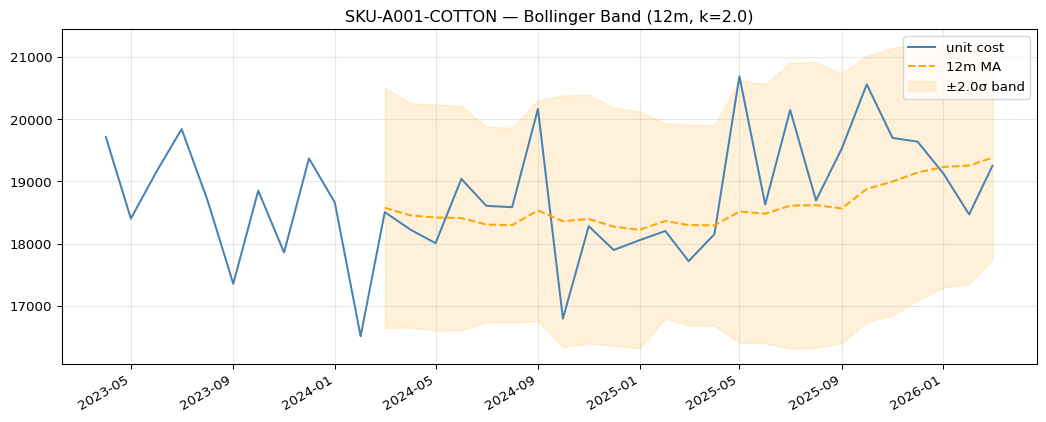

In [5]:
WINDOW = 12
K = 2.0
ma = series.rolling(WINDOW).mean()
sd = series.rolling(WINDOW).std()
upper = ma + K * sd
lower = ma - K * sd
pct_b = (series - lower) / (upper - lower)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(series.index, series, label='unit cost', color='steelblue')
ax.plot(ma.index, ma, label=f'{WINDOW}m MA', color='orange', linestyle='--')
ax.fill_between(ma.index, lower, upper, alpha=0.15, color='orange', label=f'±{K}σ band')
ax.set_title(f'{TARGET} — Bollinger Band ({WINDOW}m, k={K})')
ax.legend(); ax.grid(True, alpha=0.3)
fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(DATA_DIR / f'bollinger_{TARGET}.png', dpi=120)
plt.show()

## 3. 모멘텀 (3개월 변화율, ROC)

$\text{ROC}_t = \frac{P_t - P_{t-3}}{P_{t-3}}$

음수면 최근 3개월 가격 하락 추세.

In [6]:
momentum_3m = series.pct_change(3)
momentum_3m.tail(6).round(4)

date
2025-10-01    0.0205
2025-11-01    0.0538
2025-12-01    0.0056
2026-01-01   -0.0697
2026-02-01   -0.0624
2026-03-01   -0.0198
Freq: MS, Name: unit_cost_krw, dtype: float64

## 4. 신호 통합 — 매입 결정 테이블

In [7]:
signals = pd.DataFrame({
    'unit_cost': series,
    'trend': stl.trend,
    'z_resid': z_resid,
    'pct_b': pct_b,
    'momentum_3m': momentum_3m,
})

def label(row):
    z = row['z_resid']; m = row['momentum_3m']
    if pd.isna(z) or pd.isna(m):
        return '데이터 부족'
    if z < -1.5 and m < 0:
        return '🟢 강한 매입'
    if -1.5 <= z < -0.5 and m < 0.02:
        return '🟡 선택적 매입'
    if z > 1.0 or m > 0.05:
        return '🔴 매입 보류'
    return '⚪ 대기'

signals['action'] = signals.apply(label, axis=1)
tail = signals.tail(12).round(3)
tail

,unit_cost,trend,z_resid,pct_b,momentum_3m,action
date,,,,,,
2025-04-01,18152.0,19068.847,0.27,0.457,0.005,⚪ 대기
2025-05-01,20691.0,19117.514,0.27,1.016,0.137,🔴 매입 보류
2025-06-01,18628.0,19166.181,0.27,0.535,0.051,🔴 매입 보류
2025-07-01,20148.0,19214.848,0.27,0.835,0.110,🔴 매입 보류
2025-08-01,18693.0,19263.514,0.27,0.516,-0.097,⚪ 대기
2025-09-01,19529.0,19312.181,0.27,0.722,0.048,⚪ 대기
2025-10-01,20561.0,19360.848,0.27,0.893,0.020,⚪ 대기
2025-11-01,19699.0,19409.515,0.27,0.663,0.054,🔴 매입 보류
2025-12-01,19639.0,19458.182,0.27,0.620,0.006,⚪ 대기


## 5. 시각화 — 신호와 가격을 함께

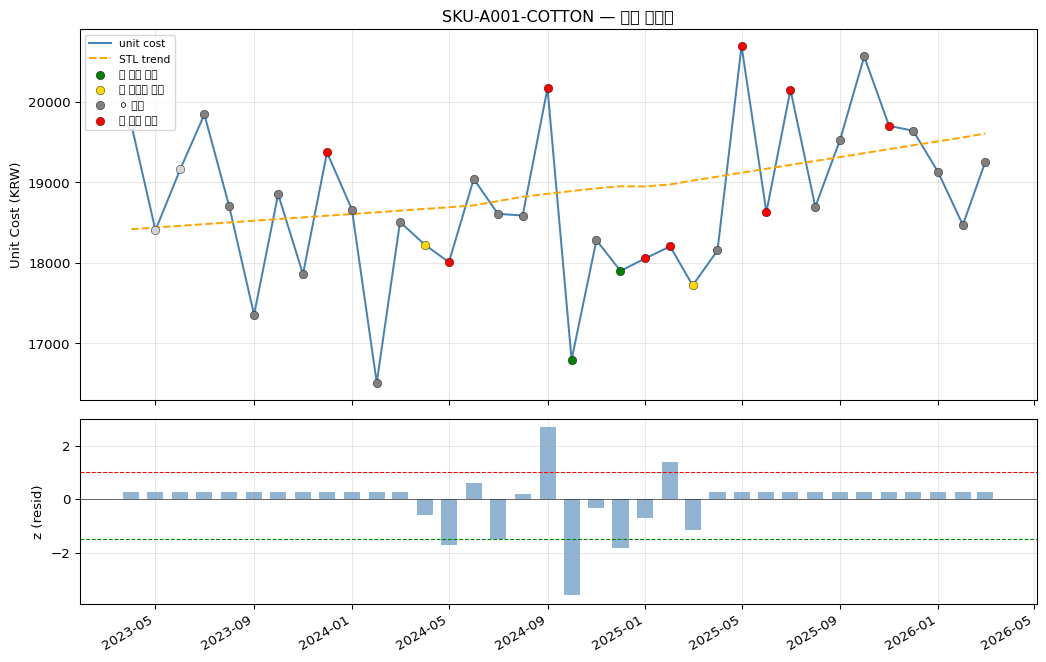

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})
ax1.plot(series.index, series, color='steelblue', label='unit cost')
ax1.plot(stl.trend.index, stl.trend, color='orange', linestyle='--', label='STL trend')
color_map = {'🟢 강한 매입': 'green', '🟡 선택적 매입': 'gold', '⚪ 대기': 'gray', '🔴 매입 보류': 'red', '데이터 부족': 'lightgray'}
for kind, color in color_map.items():
    sel = signals[signals['action'] == kind]
    if len(sel):
        ax1.scatter(sel.index, sel['unit_cost'], color=color, s=40, zorder=5,
                    edgecolor='black', linewidth=0.3, label=kind if kind != '데이터 부족' else None)
ax1.set_title(f'{TARGET} — 매입 시그널')
ax1.set_ylabel('Unit Cost (KRW)')
ax1.legend(loc='upper left', fontsize=8); ax1.grid(True, alpha=0.3)

ax2.bar(signals.index, signals['z_resid'], color='steelblue', alpha=0.6, width=20)
ax2.axhline(-1.5, color='green', linestyle='--', linewidth=0.8)
ax2.axhline(0, color='black', linewidth=0.4)
ax2.axhline(1.0, color='red', linestyle='--', linewidth=0.8)
ax2.set_ylabel('z (resid)'); ax2.grid(True, alpha=0.3)
fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(DATA_DIR / f'signals_{TARGET}.png', dpi=120)
plt.show()

## 6. "강한 매입" 신호의 사후 검증 — backtest

과거 "강한 매입" 시그널 시점에 매입했다면 평균보다 얼마나 싸게 샀을까? 이 노트북은 **단순 룩백**입니다 — 실제 의사결정 룰은 임계값 튜닝이 필요합니다.

In [9]:
avg_cost = series.mean()
buys = signals[signals['action'].isin(['🟢 강한 매입', '🟡 선택적 매입'])]
if len(buys):
    buy_avg = buys['unit_cost'].mean()
    saved_pct = (avg_cost - buy_avg) / avg_cost * 100
    print(f'전체 평균 단가: {avg_cost:,.0f} KRW')
    print(f'시그널 시점 평균 단가: {buy_avg:,.0f} KRW  ({len(buys)} 회)')
    print(f'평균 대비 절감: {saved_pct:+.2f}%')
else:
    print('과거 데이터에서 시그널이 발생하지 않음 (임계값 조정 검토)')

전체 평균 단가: 18,752 KRW
시그널 시점 평균 단가: 17,658 KRW  (4 회)
평균 대비 절감: +5.84%


## 7. 저장

In [10]:
out_csv = DATA_DIR / f'signals_{TARGET}.csv'
signals.round(3).to_csv(out_csv)
print(f'Saved → {out_csv.resolve()}')
signals.tail(6)

Saved → /Users/sungjae-cha/Documents/06 아름다운서당/next-seodang/projects/03_sales_inventory_tracker/data/signals_SKU-A001-COTTON.csv


,unit_cost,trend,z_resid,pct_b,momentum_3m,action
date,,,,,,
2025-10-01,20561.0,19360.848022,0.270476,0.893071,0.020498,⚪ 대기
2025-11-01,19699.0,19409.514844,0.270476,0.663013,0.053817,🔴 매입 보류
2025-12-01,19639.0,19458.181666,0.270476,0.620418,0.005633,⚪ 대기
2026-01-01,19128.0,19506.848488,0.270476,0.473189,-0.069695,⚪ 대기
2026-02-01,18469.0,19555.515310,0.270476,0.293105,-0.062440,⚪ 대기
2026-03-01,19251.0,19604.182132,0.270476,0.459833,-0.019757,⚪ 대기


## 다음 단계

1. `signals_*.csv`와 `signals_*.png`을 Claude Desktop에 첨부 → `procurement_strategy(si)` 프롬프트로 의사결정 narrative.
2. 가격 변동성이 크고 매크로 충격에 취약하다면 `07_derivatives_hedging.ipynb`로 헷징 시나리오 분석.
3. **주의**: 룩백 절감률은 표본에 의존. 시그널 임계값(−1.5, −0.5, 1.0)은 회사·상품별로 튜닝 필요.